In [202]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [203]:
train_data=pd.read_csv(r'D:\zag-AIprojects\car_price_prediction\data\train_car_price.csv')

In [204]:
train_data.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Random_notes
0,45806498,$8311,1273,KIA,Sportage,2020,Sedan,Yes,Petrol,2.4,17466KM,4.0,Automatic,Front,04-May,Left wheel,Black,12,NaN
1,45797469,$18346,730,HYUNDAI,Elantra,2016,Sedan,Yes,LPG,1.6,33553KM,4.0,Automatic,Front,04-May,Left wheel,Silver,4,NaN
2,45757369,$941,NaN,HONDA,Civic,2011,Sedan,Yes,Petrol,1.8,NaN,4.0,Automatic,Front,04-May,Left wheel,NaN,12,NaN
3,45789785,$6272,-,VOLKSWAGEN,Golf,2001,Universal,No,Petrol,2,256000KM,4.0,Manual,Front,04-May,Left wheel,Black,4,NaN
4,45709410,$2822,NaN,MERCEDES-BENZ,A 190,1987,Sedan,No,Petrol,2,NaN,4.0,Manual,Rear,04-May,Left wheel,NaN,0,NaN


In [205]:
train_data.shape

(15789, 19)

In [206]:
train_data.columns

Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags', 'Random_notes'],
      dtype='str')

In [207]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 15789 entries, 0 to 15788
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                15789 non-null  int64  
 1   Price             15789 non-null  str    
 2   Levy              14421 non-null  str    
 3   Manufacturer      15789 non-null  str    
 4   Model             15789 non-null  str    
 5   Prod. year        15789 non-null  int64  
 6   Category          15789 non-null  str    
 7   Leather interior  15789 non-null  str    
 8   Fuel type         15789 non-null  str    
 9   Engine volume     15789 non-null  str    
 10  Mileage           14421 non-null  str    
 11  Cylinders         15789 non-null  float64
 12  Gear box type     15789 non-null  str    
 13  Drive wheels      15789 non-null  str    
 14  Doors             15789 non-null  str    
 15  Wheel             15789 non-null  str    
 16  Color             14421 non-null  str    
 17  Airb

In [208]:
train_data.dtypes

ID                    int64
Price                   str
Levy                    str
Manufacturer            str
Model                   str
Prod. year            int64
Category                str
Leather interior        str
Fuel type               str
Engine volume           str
Mileage                 str
Cylinders           float64
Gear box type           str
Drive wheels            str
Doors                   str
Wheel                   str
Color                   str
Airbags               int64
Random_notes        float64
dtype: object

In [209]:
train_data.nunique()

ID                  15387
Price                2094
Levy                  503
Manufacturer           63
Model                1395
Prod. year             54
Category               11
Leather interior        2
Fuel type               6
Engine volume         104
Mileage              6190
Cylinders              12
Gear box type           4
Drive wheels            3
Doors                   3
Wheel                   2
Color                  16
Airbags                17
Random_notes            0
dtype: int64

# Data Cleaning

* Handle Data types

In [210]:
train_data.isnull().sum()

ID                      0
Price                   0
Levy                 1368
Manufacturer            0
Model                   0
Prod. year              0
Category                0
Leather interior        0
Fuel type               0
Engine volume           0
Mileage              1368
Cylinders               0
Gear box type           0
Drive wheels            0
Doors                   0
Wheel                   0
Color                1368
Airbags                 0
Random_notes        15789
dtype: int64

In [211]:
train_data['Price']=train_data['Price'].str.replace('$','').astype(float)

In [212]:
train_data['Levy'].unique()

<StringArray>
['1273',  '730',    nan,    '-',  '862', '1053',  '777',  '584', '1360',
  '779',
 ...
 '2658', '1466', '3329', '1836', '1285', '2908', '4860', '2705',  '556',
 '2736']
Length: 504, dtype: str

In [213]:
train_data['Levy']=train_data['Levy'].str.replace('-','nan').astype(float)

In [214]:
train_data['Engine volume']=train_data['Engine volume'].str.replace('Turbo','').astype(float)

In [215]:
train_data['Mileage']=train_data['Mileage'].str.replace('KM','').astype(float)

In [216]:
train_data['Doors'] = train_data['Doors'].replace({'02-Mar': 2, '04-May': 4, '>5': 5})
train_data['Doors'] = train_data['Doors'].astype(int)

In [217]:
train_data.dtypes

ID                    int64
Price               float64
Levy                float64
Manufacturer            str
Model                   str
Prod. year            int64
Category                str
Leather interior        str
Fuel type               str
Engine volume       float64
Mileage             float64
Cylinders           float64
Gear box type           str
Drive wheels            str
Doors                 int64
Wheel                   str
Color                   str
Airbags               int64
Random_notes        float64
dtype: object

* Handle null values

In [218]:
train_data.isnull().sum()

ID                      0
Price                   0
Levy                 5743
Manufacturer            0
Model                   0
Prod. year              0
Category                0
Leather interior        0
Fuel type               0
Engine volume           0
Mileage              1368
Cylinders               0
Gear box type           0
Drive wheels            0
Doors                   0
Wheel                   0
Color                1368
Airbags                 0
Random_notes        15789
dtype: int64

In [219]:
train_data['Levy']=train_data['Levy'].fillna(train_data['Levy'].mean())

In [220]:
train_data['Mileage']=train_data['Mileage'].fillna(train_data['Mileage'].mean())

In [221]:
train_data['Color']=train_data['Color'].fillna(train_data['Color'].mode()[0])

In [222]:
train_data['Random_notes'] = train_data['Random_notes'].fillna('nan')

In [223]:
train_data.isnull().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
Random_notes        0
dtype: int64

* Handle Duplicates

In [224]:
train_data.duplicated().sum()

np.int64(378)

In [225]:
train_data.drop_duplicates(inplace=True)

In [226]:
train_data.duplicated().sum()

np.int64(0)

* Handle Outliers

In [227]:
numerical_features=train_data.select_dtypes(include='number')
categorical_features=train_data.select_dtypes(include=['string','object'])

In [228]:
def oulier_detection(df):
    for col in numerical_features:
        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)
        IQR=Q3-Q1
        lower_bound=Q1-1.5*IQR
        upper_bound=Q3+1.5*IQR
        ouliers_count=((df[col]<lower_bound) | (df[col]>upper_bound)).sum()
        per_outliers=(ouliers_count/len(df))*100
        print(f"{col}:{per_outliers.__round__(2)}%")

In [229]:
oulier_detection(train_data)

ID:13.41%
Price:5.42%
Levy:19.28%
Prod. year:5.02%
Engine volume:7.13%
Mileage:9.8%
Cylinders:25.22%
Doors:4.79%
Airbags:0.0%


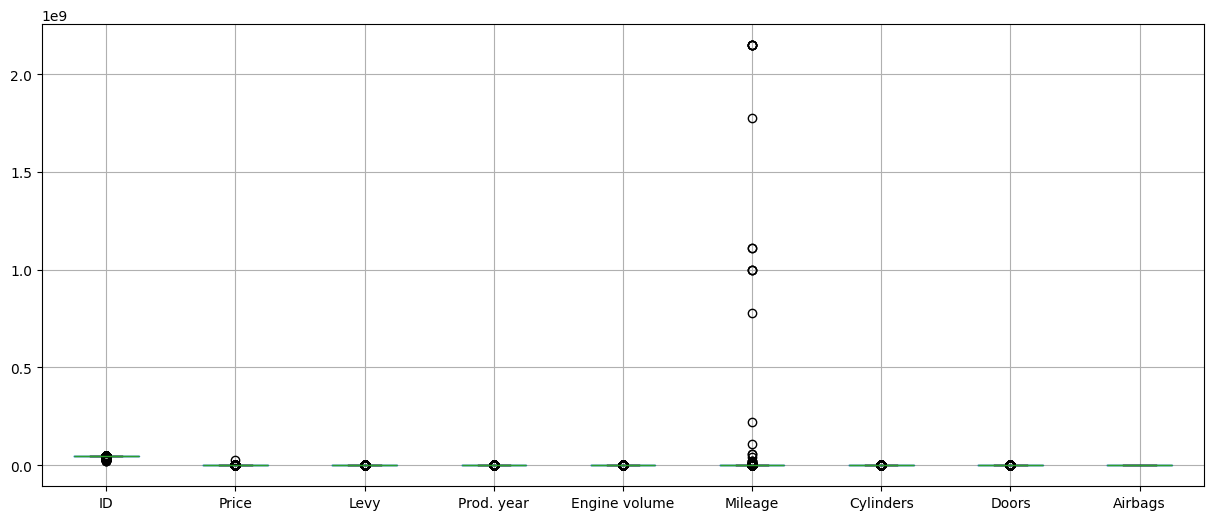

In [230]:
train_data.boxplot(figsize=(15,6))
plt.show()

In [231]:
for col in numerical_features:
    Q1=train_data[col].quantile(0.25)
    Q3=train_data[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    train_data[col]=train_data[col].clip(lower=lower_bound,upper=upper_bound)

In [232]:
oulier_detection(train_data)

ID:0.0%
Price:0.0%
Levy:0.0%
Prod. year:0.0%
Engine volume:0.0%
Mileage:0.0%
Cylinders:0.0%
Doors:0.0%
Airbags:0.0%


# Data Visualization

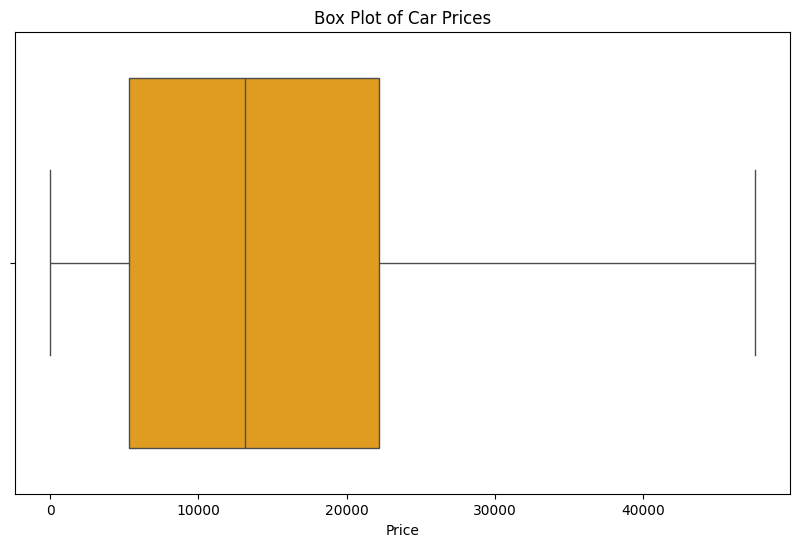

In [233]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=train_data['Price'], color='orange')
plt.title('Box Plot of Car Prices')
plt.show()

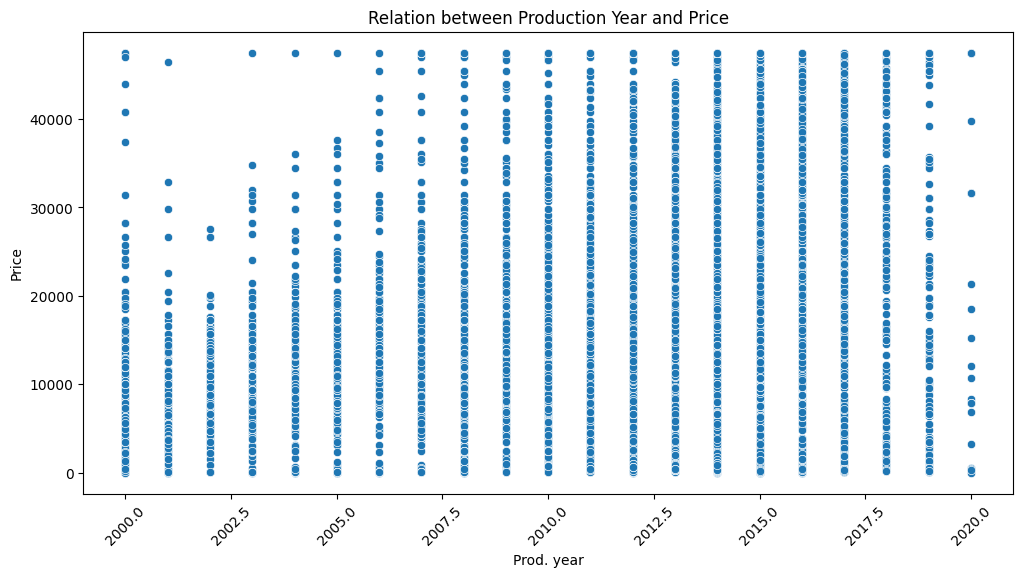

In [234]:
plt.figure(figsize=(12, 6))
df_year = train_data[train_data['Prod. year'] != 'unknown']
sns.scatterplot(data=df_year, x='Prod. year', y='Price')
plt.title('Relation between Production Year and Price')
plt.xticks(rotation=45)
plt.show()

لمعرفة أي الماركات هي الأغلى في بياناتك.

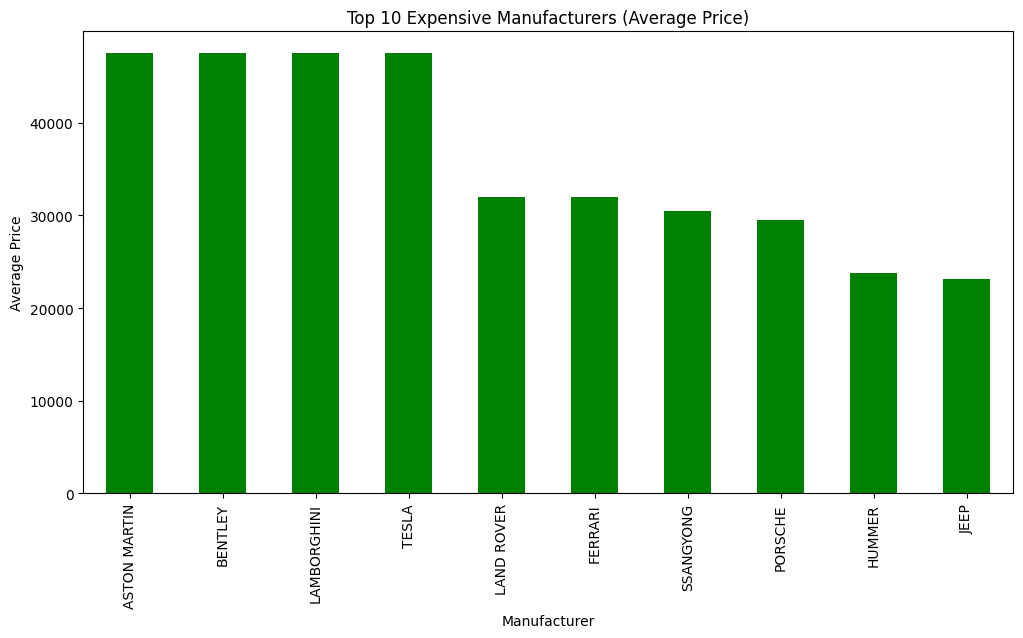

In [235]:
plt.figure(figsize=(12, 6))
top_brands = train_data.groupby('Manufacturer')['Price'].mean().sort_values(ascending=False).head(10)
top_brands.plot(kind='bar', color='green')
plt.title('Top 10 Expensive Manufacturers (Average Price)')
plt.ylabel('Average Price')
plt.show()

لرؤية توزيع الأسعار لكل نوع وقود

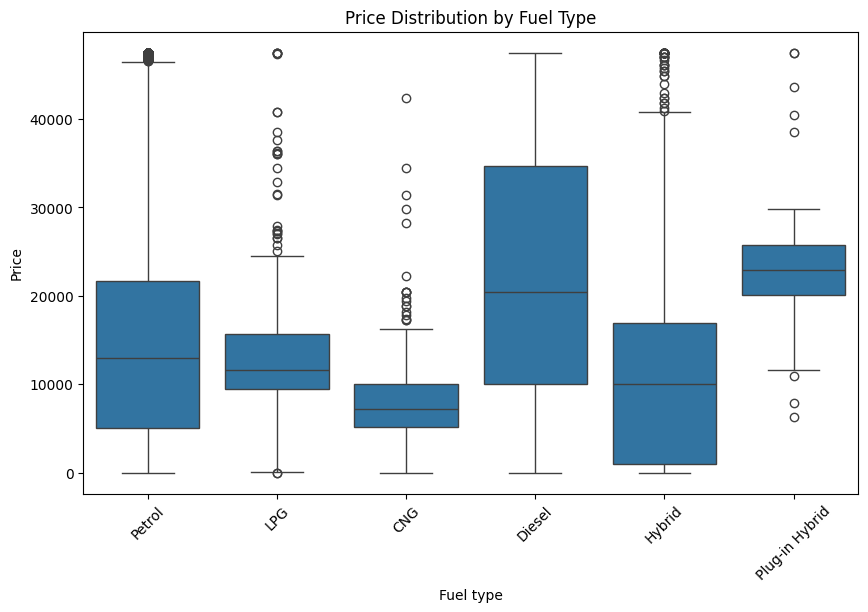

In [236]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Fuel type', y='Price', data=train_data)
plt.title('Price Distribution by Fuel Type')
plt.xticks(rotation=45)
plt.show()

هذا الرسم هو الأهم لفهم أي العوامل تؤثر فعلياً في السعر (مثل حجم المحرك، السلندرات)

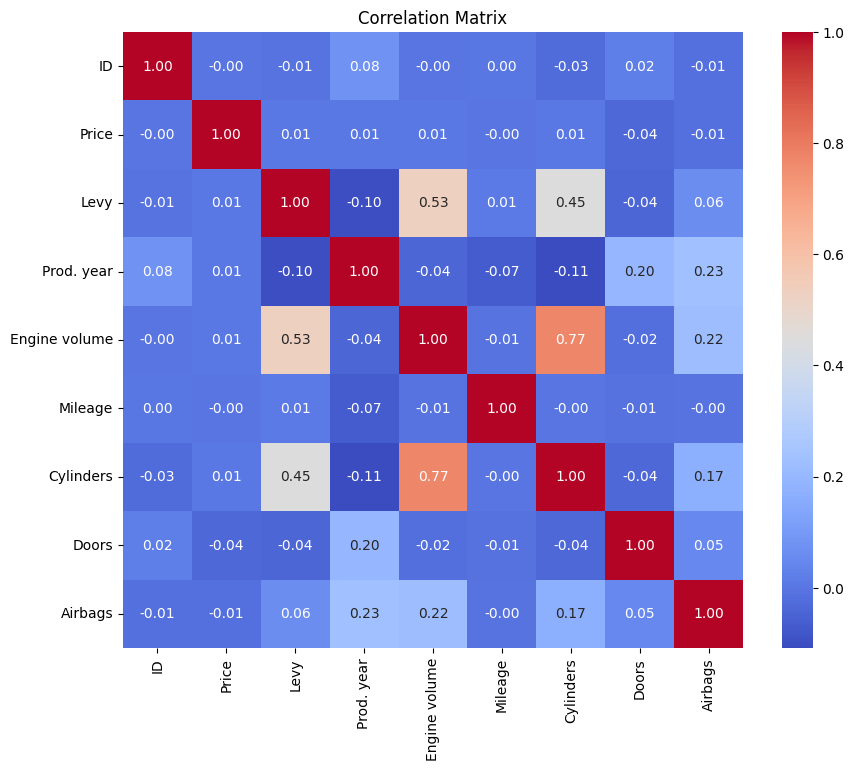

In [237]:
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_features.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

تحليل عمود السعر

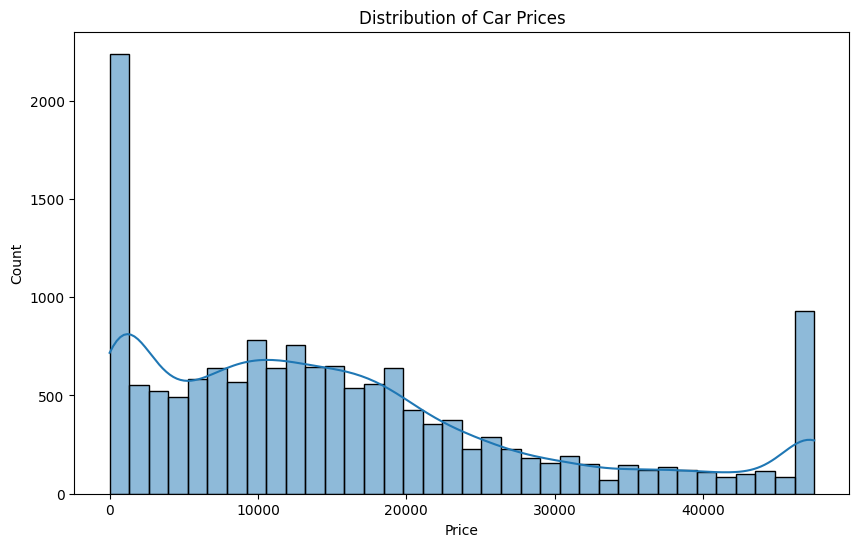

In [244]:
plt.figure(figsize=(10, 6))
sns.histplot(train_data['Price'], kde=True)
plt.title('Distribution of Car Prices')
plt.show()

 العلاقة بين سنة الصنع والسعر

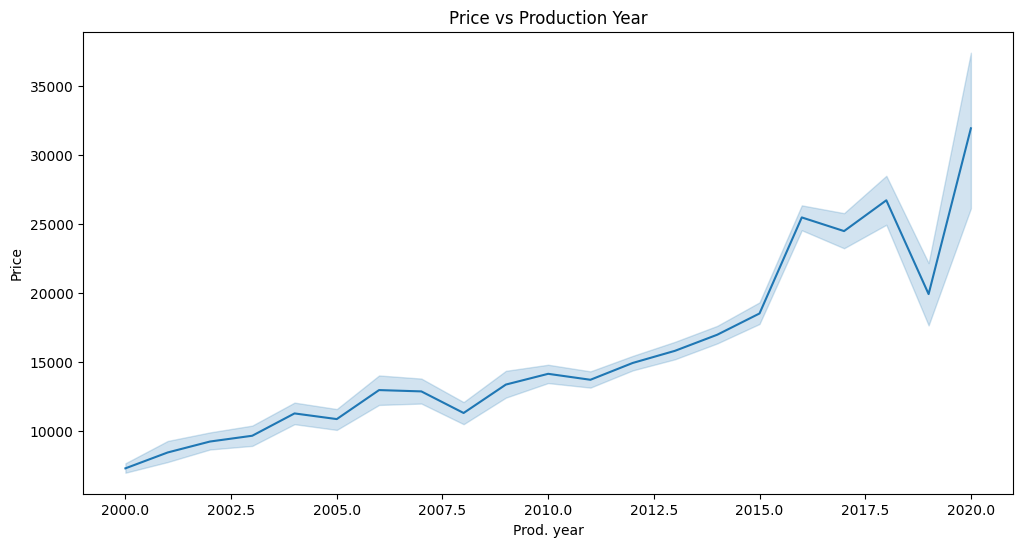

In [245]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Prod. year', y='Price', data=train_data)
plt.title('Price vs Production Year')
plt.show()